> # **사기 거래 집중 학습 모델(RandomForest)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
##데이터 불러오기

In [ ]:
############################################## 00. 필요한 파이썬 라이브러리 불러오기 #####################################################
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# Plotly
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

from sklearn.model_selection import train_test_split

import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.svm import OneClassSVM

from scipy.stats import pearsonr, chi2_contingency
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
# train 데이터
data = pd.read_csv('/content/drive/MyDrive/Data.csv')
data.head()

,User,Gender,Current Age,Retirement Age,Birth Year,Birth Month,Zipcode,Per Capita Income - Zipcode,Yearly Income,Total Debt,...,Card Number,Expires,Has Chip,Credit Limit,Acct Open Date,Year PIN last Changed,Amount,Whether Security Chip is Used,Error Message,Is Fraud?
0,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,84600.0,0,NaN,No
1,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,72100.0,0,NaN,No
2,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,3300.0,1,NaN,No
3,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,56800.0,0,NaN,No
4,0,0,53,66,1966,11,8250.0,17420410,52077100.0,9.088794e+07,...,5.655323e+15,12/2022,True,14455525,09/2002,2008,104600.0,0,NaN,No


In [ ]:
data['Expires'] = pd.to_datetime(data['Expires'], format='%m/%Y')
data['Acct Open Date'] = pd.to_datetime(data['Acct Open Date'], format='%m/%Y')

In [ ]:
# 'Expires' 칼럼에서 연도와 월 추출
data['Expires_Year'] = data['Expires'].dt.year
data['Expires_Month'] = data['Expires'].dt.month

# 'Acct Open Date' 칼럼에서 연도와 월 추출
data['AcctOpen_Year'] = data['Acct Open Date'].dt.year
data['AcctOpen_Month'] = data['Acct Open Date'].dt.month

data = data.drop(columns=['Expires', 'Acct Open Date'])

In [ ]:
#높은 상관관계를 가지는 feature 제거
data = data.drop(['Error Message'], axis=1, errors='ignore')
data = data.drop(['Year', 'Card'], axis=1, errors='ignore')

In [ ]:
num_feat = data.select_dtypes('number').columns.values
comb_num_feat = np.array(list(combinations(num_feat, 2)))
corr_num_feat = np.array([])
for comb in comb_num_feat:
    corr = pearsonr(data[comb[0]], data[comb[1]])[0]
    corr_num_feat = np.append(corr_num_feat, corr)

high_corr_num = comb_num_feat[np.abs(corr_num_feat) >= 0.9]
data = data.drop(np.unique(high_corr_num[:, 0]), axis=1, errors='ignore')

In [ ]:
#범주형 데이터 처리
#Card Brand, Card Type
data = pd.get_dummies(data, columns=['Card Brand', 'Card Type'])

#Is Fraud?
data['Is Fraud?'] = data['Is Fraud?'].map({'Yes': 1, 'No': 0})

is_fraud = data.pop('Is Fraud?')
data['Is Fraud?'] = is_fraud

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1644768 entries, 0 to 1644767
Data columns (total 30 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   User                           1644768 non-null  int64  
 1   Gender                         1644768 non-null  int64  
 2   Retirement Age                 1644768 non-null  int64  
 3   Birth Year                     1644768 non-null  int64  
 4   Birth Month                    1644768 non-null  int64  
 5   Zipcode                        1644768 non-null  float64
 6   Per Capita Income - Zipcode    1644768 non-null  int64  
 7   Yearly Income                  1644768 non-null  float64
 8   Total Debt                     1644768 non-null  float64
 9   Credit Score                   1644768 non-null  int64  
 10  Month                          1644768 non-null  int64  
 11  Day                            1644768 non-null  int64  
 12  Merchandise Co

> ## **학습 데이터와 테스트 데이터 분리**

In [ ]:
#fraudid: 한 번 이상 사기 당한 user
llist = []
cnt=0
cnt2=0
fraudid = data.loc[data['Is Fraud?'] == 1,'User'].unique()
for i in fraudid:
    #User의 모든 거래 총 건수
    User_all = data.loc[data['User'] == i]
    #User의 거래 건수 중 사기 당한 총 건수
    User_Fraud = data.loc[(data['User'] == i) & (data['Is Fraud?'] == 1)]
    if (User_Fraud.shape[0]>1):
      cnt+=1
    else:
      cnt2+=1
    llist.append({'User': i,'User_All': User_all.shape[0],
                 'Fraud': User_Fraud.shape[0]})

result_df = pd.DataFrame(llist)
print(result_df)

     User  User_All  Fraud
0       2      2715     23
1       5      1247      9
2      23       507     11
3      29      1167     12
4      37       451      9
..    ...       ...    ...
228  1890      1193      1
229  1921       901      7
230  1931      1101      6
231  1996       949      8
232  1997      1336      9

[233 rows x 3 columns]


In [ ]:
#1번 이상 Fraud 당한 User
Fraud_user=data[data['Is Fraud?']==1].User.unique()

#1번 이상 Fraud 당한 User들의 모든 거래 건수
df_fraud=data[data['User'].isin(Fraud_user)]

#Fraud 1/0 count
fraud_1_0_count=df_fraud['Is Fraud?'].value_counts()
fraud_1_0_count

,count
Is Fraud?,
0,251075
1,2321


In [ ]:
#feature와 label 분리(학습 데이터): 사기 관련 데이터
X_train = df_fraud.drop(columns=['Is Fraud?'])
Y_train = df_fraud['Is Fraud?']

#feature와 label 분리(테스트 데이터): 전체 데이터
X_test=data.drop(columns=['Is Fraud?'])
Y_test = data['Is Fraud?']

> ## **RandomForest 모델을 사용한 학습 및 테스트**

In [ ]:
#학습
model=RandomForestClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
Y_pred_proba = model.predict_proba(X_test)[:, 1] #예측 확률

AUC-ROC: 0.9999999
F1-Score: 0.9952830
Precision: 0.9906103
Recall: 1.0000000


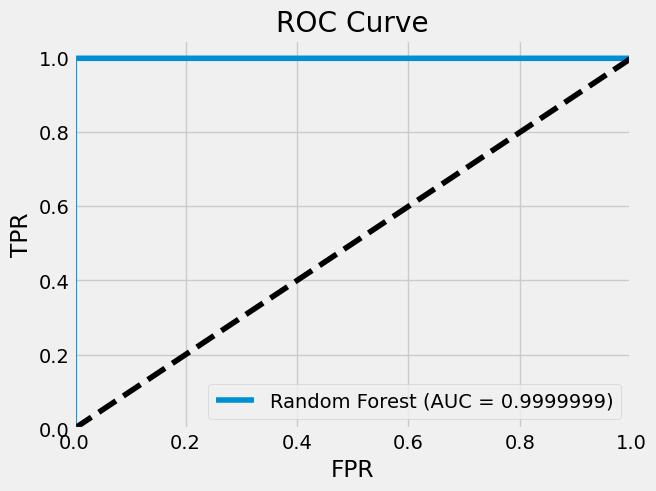

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score

name="Random Forest"

#AUC-ROC
auc = roc_auc_score(Y_test, Y_pred_proba)
print(f"AUC-ROC: {auc:.7f}")

#F1-score
f1 = f1_score(Y_test, Y_pred)
print(f"F1-Score: {f1:.7f}")

#Precision
precision = precision_score(Y_test, Y_pred)
print(f"Precision: {precision:.7f}")

#Recall
recall = recall_score(Y_test, Y_pred)
print(f"Recall: {recall:.7f}")

# ROC Curve 그리기
fpr, tpr, _ = roc_curve(Y_test, Y_pred_proba)
plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.7f})')

# ROC Curve 그래프
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

Accuracy:  99.998662425339


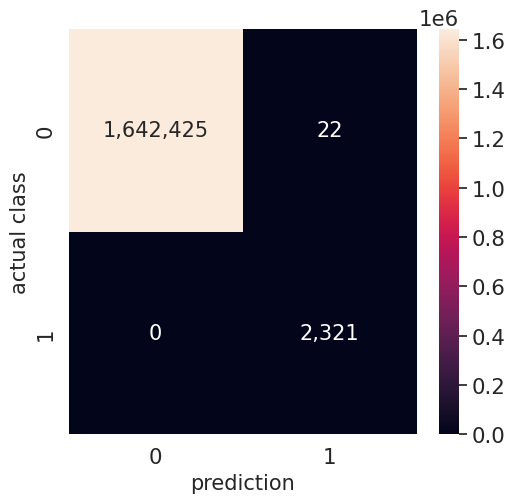

In [ ]:
#Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
plt.rcParams['figure.figsize'] = (5, 5)
sns.set(style = 'white', font_scale = 1.4)
ax=sns.heatmap(cm, annot = True, annot_kws = {"size": 15},fmt=',')
ax.set_xlabel('prediction',fontsize=15)
ax.set_ylabel('actual class',fontsize=15)
print("Accuracy: ", model.score(X_test,Y_test)*100)